In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [2]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"]=(10,5)

In [3]:
df=pd.read_csv("customer_master.csv")

In [5]:
df.head()

,customer_id,customer_name,customer_age,gender,customer_segment,customer_city,customer_state,customer_country,region,customer_postal_code,customer_acquisition_cost
0,CUST-000001,Donna Miller,54,Female,Consumer,Laurenland,Dubai,UAE,South,11253,13.58
1,CUST-000002,Joseph James,61,Male,Consumer,Lake Peter,Lower Saxony,Germany,North,47778,27.45
2,CUST-000003,Daniel Smith,47,Male,Consumer,Seanview,North Rhine,Germany,West,13900,31.53
3,CUST-000004,David Lopez,30,Male,VIP,Hawkinshaven,Pennsylvania,USA,East,53984,16.02
4,CUST-000005,Dakota Davis,55,Female,Consumer,New Carlymouth,Florida,USA,South,50994,41.34


In [6]:
df.shape

(25000, 11)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                25000 non-null  object 
 1   customer_name              25000 non-null  object 
 2   customer_age               25000 non-null  int64  
 3   gender                     25000 non-null  object 
 4   customer_segment           25000 non-null  object 
 5   customer_city              25000 non-null  object 
 6   customer_state             25000 non-null  object 
 7   customer_country           25000 non-null  object 
 8   region                     25000 non-null  object 
 9   customer_postal_code       25000 non-null  int64  
 10  customer_acquisition_cost  25000 non-null  float64
dtypes: float64(1), int64(2), object(8)
memory usage: 2.1+ MB


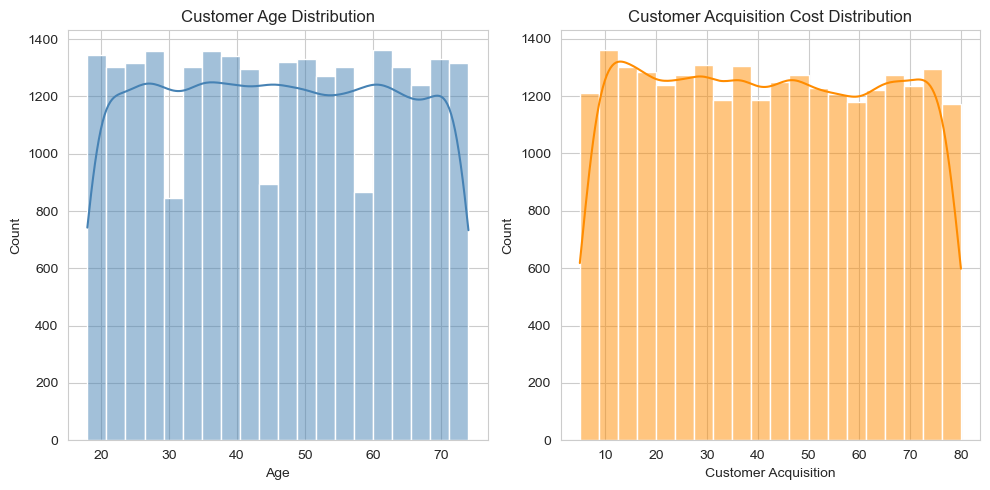

In [10]:
fig , axes = plt.subplots(1,2)
sns.histplot(df["customer_age"], bins=20, kde=True , ax=axes[0],color="steelblue")
axes[0].set_title("Customer Age Distribution")
axes[0].set_xlabel("Age")
sns.histplot(df["customer_acquisition_cost"], bins=20, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Customer Acquisition Cost Distribution")
axes[1].set_xlabel("Customer Acquisition")
plt.tight_layout()
plt.show()

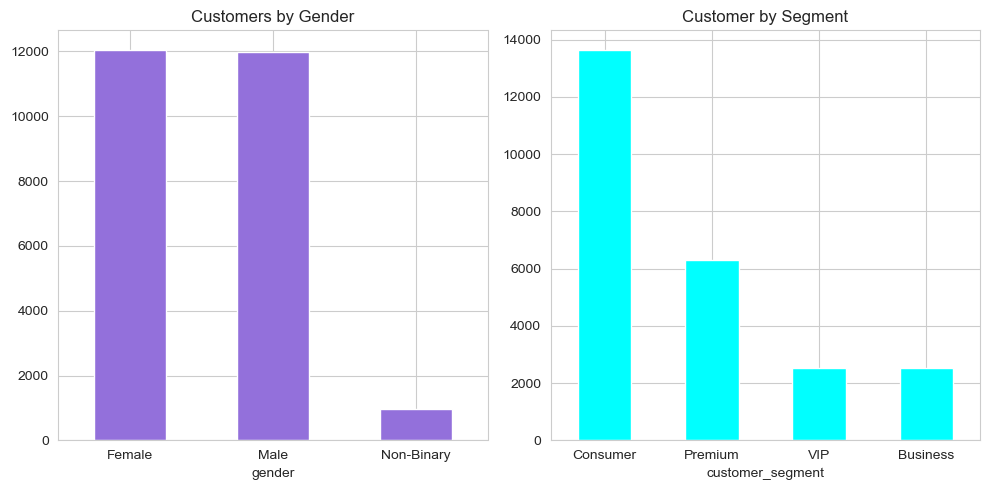

In [9]:
fig, axes = plt.subplots(1,2)
df["gender"].value_counts().plot(kind="bar", ax=axes[0], color="mediumpurple")
axes[0].set_title("Customers by Gender")
axes[0].tick_params(axis='x', rotation=0)

df["customer_segment"].value_counts().plot(kind="bar", ax=axes[1], color="cyan")
axes[1].set_title("Customer by Segment")
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


In [19]:
unique_ids=df["customer_id"].is_unique
duplicate_rows=df.duplicated().sum()
duplicated_name=df["customer_name"].duplicated().sum()

In [17]:
pd.Series({
    'Unique ids':unique_ids,
    'Duplicated Rows': duplicate_rows,
    'duplicated_name': duplicated_name
})

Unique ids         True
Duplicated Rows       0
duplicated_name    3369
dtype: object

In [21]:
country_summary = df.groupby("customer_country").agg(
    customer_count = ("customer_id", "count"),
    avg_age = ("customer_age", "mean"),
    avg_acquisition_cost = ("customer_acquisition_cost", "mean")
).sort_values("customer_count", ascending=False)

In [22]:
country_summary

,customer_count,avg_age,avg_acquisition_cost
customer_country,,,
USA,14925,45.928777,42.085881
UK,3701,45.883545,42.274712
Germany,2046,45.640762,42.217571
Canada,1279,46.275215,42.612651
Australia,1233,45.689376,42.972758
India,1041,46.024976,41.831585
UAE,775,45.909677,41.280594


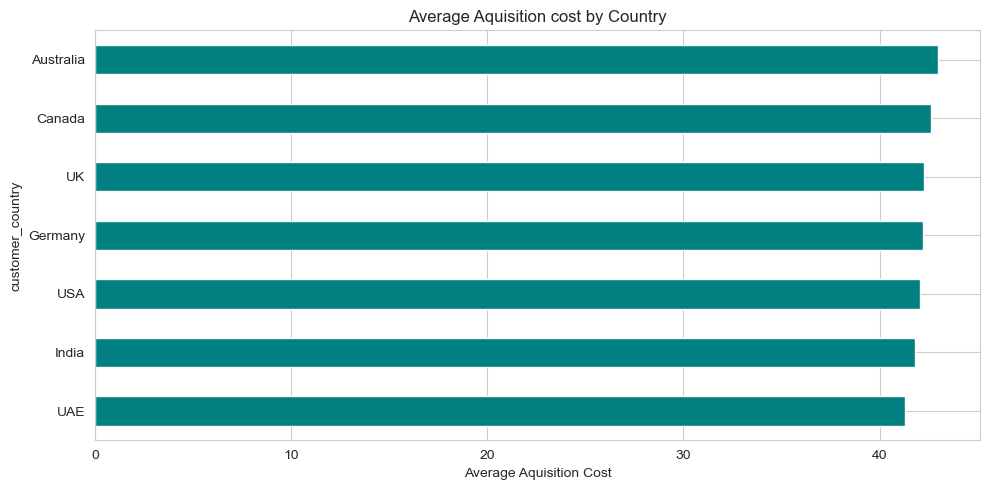

In [25]:
country_summary["avg_acquisition_cost"].sort_values().plot(kind='barh', color='teal')
plt.title('Average Aquisition cost by Country')
plt.xlabel('Average Aquisition Cost')
plt.tight_layout()
plt.show()

In [4]:
df.columns

Index(['customer_id', 'customer_name', 'customer_age', 'gender',
       'customer_segment', 'customer_city', 'customer_state',
       'customer_country', 'region', 'customer_postal_code',
       'customer_acquisition_cost'],
      dtype='object')

               customer_count   avg_cost
customer_city                           
South Michael              30  42.896333
Lake Michael               30  39.734667
East Michael               23  43.170435
Port Michael               21  41.087619
South James                20  51.139000
New David                  19  40.005789
New Robert                 18  46.612222
North David                17  44.746471
West Michael               17  46.889412
New John                   17  35.076471


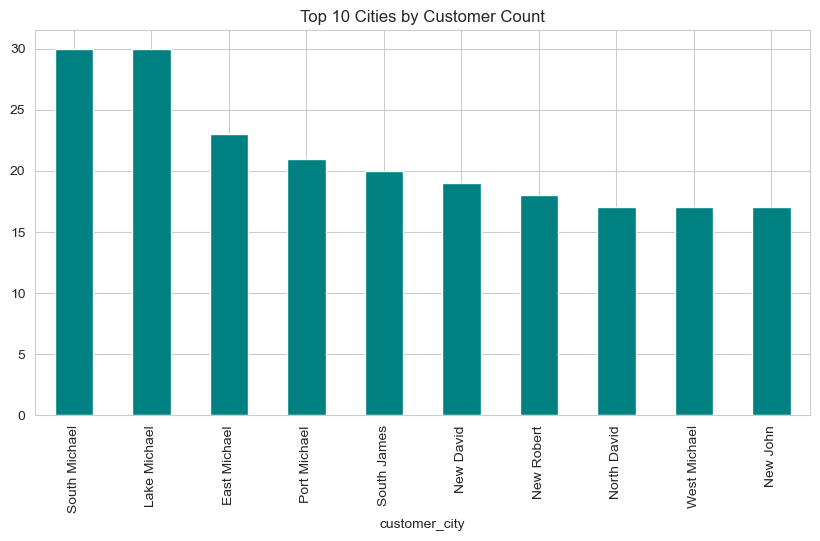

In [15]:
# Top 10 cities by customer count
city_summary = df.groupby('customer_city').agg(
    customer_count=('customer_id', 'count'),
    avg_cost=('customer_acquisition_cost', 'mean')
).sort_values('customer_count', ascending=False).head(10)
print(city_summary)
city_summary['customer_count'].plot(kind='bar', color='teal')
plt.title('Top 10 Cities by Customer Count')
plt.show()

# # Region analysis
# region_summary = df.groupby('region').agg(
#     customer_count=('customer_id', 'count'),
#     avg_cost=('customer_acquisition_cost', 'mean'),
#     avg_age=('customer_age', 'mean')
# )

# # Visualize region distribution
# sns.barplot(data=region_summary.reset_index(), x='region', y='customer_count', palette='viridis')
# plt.title('Customers by Region')
# plt.show()

# # State-level analysis (top 10)
# state_summary = df.groupby('customer_state').agg(
#     customer_count=('customer_id', 'count'),
#     avg_cost=('customer_acquisition_cost', 'mean')
# ).sort_values('customer_count', ascending=False).head(10)

# state_summary.plot(kind='bar', y='avg_cost', color='coral')
# plt.title('Top 10 States by Avg Acquisition Cost')
# plt.show()


         customer_count   avg_cost
region                            
South              7996  42.234782
Central            5358  42.171934
West               4750  42.143261
East               3874  41.820741
North              3022  42.400126


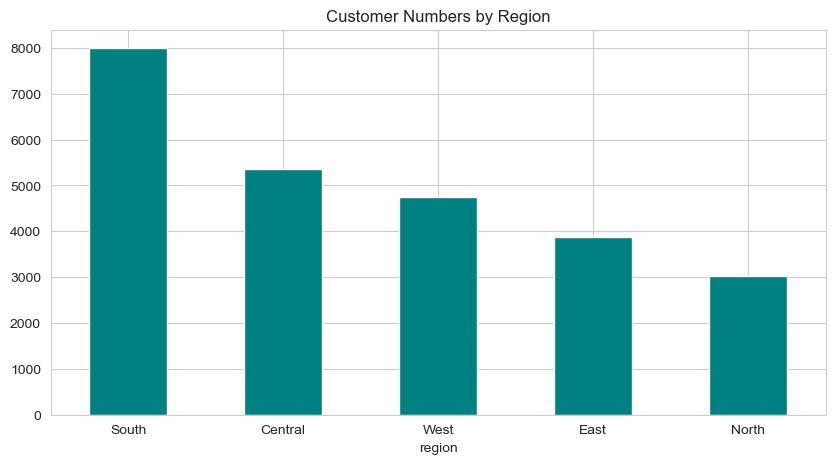

In [25]:
# df.head()
# data science
region_summary=df.groupby('region').agg(
    customer_count=('customer_id', 'count'),
    avg_cost=('customer_acquisition_cost', 'mean')).sort_values('customer_count', ascending=False)
print(region_summary)

region_summary['customer_count'].plot(kind='bar', color='teal')
plt.title('Customer Numbers by Region')
plt.tick_params(axis='x', rotation=0)
plt.show()

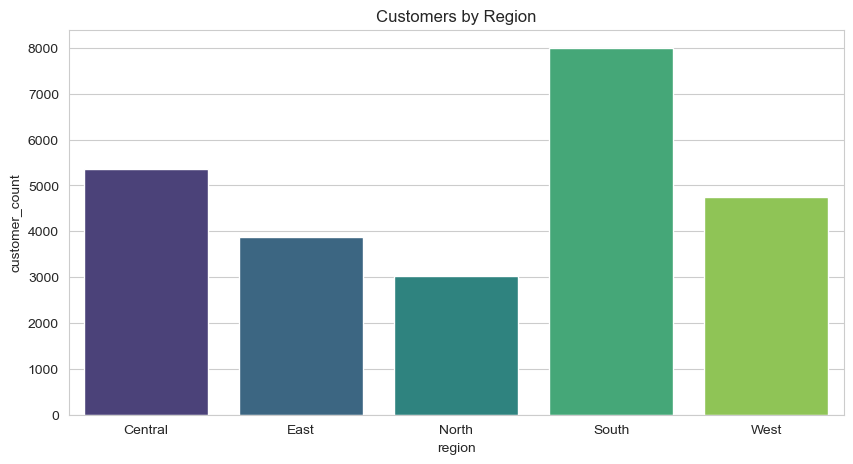

In [30]:
# Region analysis
region_summary = df.groupby('region').agg(
    customer_count=('customer_id', 'count'),
    avg_cost=('customer_acquisition_cost', 'mean'),
    avg_age=('customer_age', 'mean')
)

# Visualize region distribution
sns.barplot(data=region_summary.reset_index(), x='region', y='customer_count', hue='region', palette='viridis')
plt.title('Customers by Region')
plt.tick_params(axis='x', rotation=0)
plt.show()

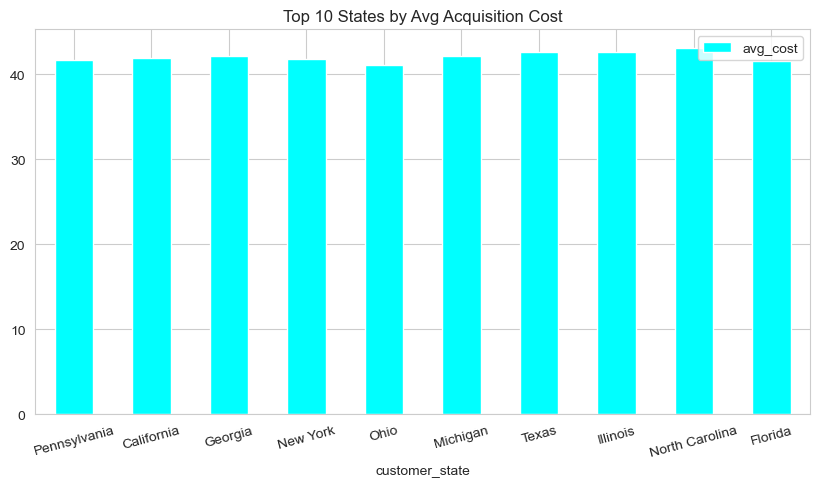

In [37]:
# State-level analysis (top 10)
state_summary = df.groupby('customer_state').agg(
    customer_count=('customer_id', 'count'),
    avg_cost=('customer_acquisition_cost', 'mean')
).sort_values('customer_count', ascending=False).head(10)

state_summary.plot(kind='bar', y='avg_cost', color='cyan')
plt.title('Top 10 States by Avg Acquisition Cost')
plt.tick_params(axis='x', rotation=15)
plt.show()


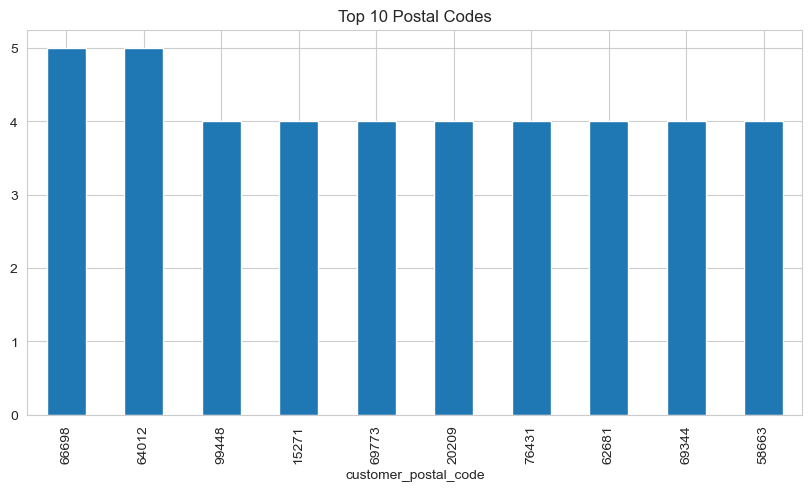

In [42]:
df['customer_postal_code'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Postal Codes')

plt.show()

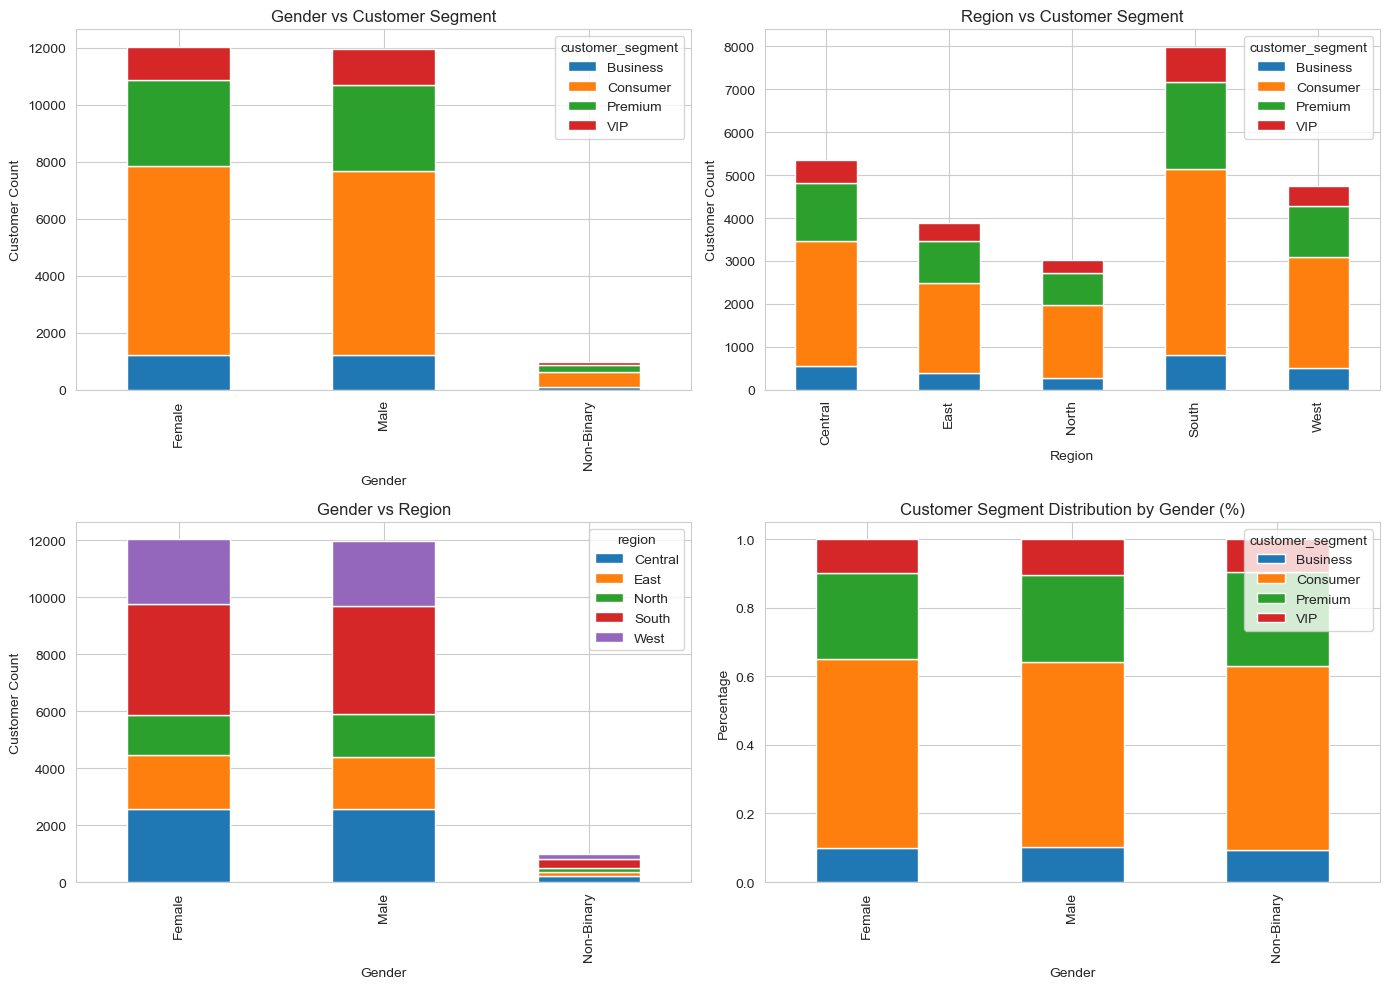

In [49]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gender vs Segment
pd.crosstab(
    df['gender'],
    df['customer_segment']
).plot(
    kind='bar',
    stacked=True,
    ax=axes[0, 0]
)

axes[0, 0].set_title('Gender vs Customer Segment')
axes[0, 0].set_xlabel('Gender')
axes[0, 0].set_ylabel('Customer Count')


# Region vs Segment
pd.crosstab(
    df['region'],
    df['customer_segment']
).plot(
    kind='bar',
    stacked=True,
    ax=axes[0, 1]
)

axes[0, 1].set_title('Region vs Customer Segment')
axes[0, 1].set_xlabel('Region')
axes[0, 1].set_ylabel('Customer Count')


# Gender vs Region
pd.crosstab(
    df['gender'],
    df['region']
).plot(
    kind='bar',
    stacked=True,
    ax=axes[1, 0]
)

axes[1, 0].set_title('Gender vs Region')
axes[1, 0].set_xlabel('Gender')
axes[1, 0].set_ylabel('Customer Count')


# Normalized version (%)
pd.crosstab(
    df['gender'],
    df['customer_segment'],
    normalize='index'
).plot(
    kind='bar',
    stacked=True,
    ax=axes[1, 1]
)

axes[1, 1].set_title('Customer Segment Distribution by Gender (%)')
axes[1, 1].set_xlabel('Gender')
axes[1, 1].set_ylabel('Percentage')


plt.tight_layout()
# plt.savefig('pic')
plt.show()

In [46]:
pd.crosstab(
    df['gender'],
    df['customer_segment']
)

customer_segment,Business,Consumer,Premium,VIP
gender,,,,
Female,1206,6641,3018,1183
Male,1223,6472,3017,1264
Non-Binary,90,525,266,95
